# Module 06 — EDA Interactive Notebook
## Insurance Claims and Risk Analytics

---

### How to use this notebook
Run cells from top to bottom using **Shift+Enter**.
Each cell has a comment explaining what it does and why.

This notebook is the **interactive layer** on top of `run.py`.
While `run.py` produces text reports, this notebook produces:
- Visual charts (histograms, box plots, scatter plots, heatmaps)
- Interactive exploration of specific findings
- Deeper investigation of anomalies

**Business questions we answer here:**
1. Which insurance policy types and claim types generate the highest average claim amount?
2. Which claim types are underperforming or unusual relative to the policy_type average?
3. Does risk_score correlate with claim amount or approved amount?
4. Which specific insurance claims are statistical anomalies?


In [1]:
# ── Cell 1: Imports and Setup ─────────────────────────────────────────────
# Before anything else, we import the libraries we need.
# These are the standard imports for any EDA notebook.

import sys
import pathlib

# Add the project root to Python path so we can import our classes
# pathlib.Path.cwd() returns the current working directory
# We walk up until we find config.py
_root = pathlib.Path.cwd()
while not (_root / "config.py").exists() and _root != _root.parent:
    _root = _root.parent

if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt   # matplotlib: the core Python plotting library

# Tell matplotlib to display plots directly in the notebook (not in a separate window)
%matplotlib inline

# Set figure defaults for readable notebook charts
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

from config import DATA_PATH, REPORTS_DIR, TOP_N_GROUPS

# Create folder for notebook chart outputs
FIGURES_DIR = REPORTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
from src.eda_engine import EDAEngine
from src.anomaly_detector import AnomalyDetector

print(f"Project root: {_root}")
print(f"Data path:    {DATA_PATH}")
print(f"Reports dir:  {REPORTS_DIR}")
print(f"Figures dir:  {FIGURES_DIR}")


2026-05-24 14:51:20 [INFO] Insurance database connection successful.


Project root: c:\student-projects eda\P03-insurance-eda
Data path:    C:\student-projects eda\P03-insurance-eda\data\processed\processed-data.csv
Reports dir:  C:\student-projects eda\P03-insurance-eda\reports
Figures dir:  C:\student-projects eda\P03-insurance-eda\reports\figures


In [2]:
# ── Cell 2: Load and Profile the Data ────────────────────────────────────
# We use our EDAEngine class to load and profile the data.
# This is the same code that run.py executes — but here we can
# inspect intermediate results interactively.

engine = EDAEngine()
engine.load().profile()

# Access the profile results dictionary directly
p = engine.results["profile"]

print("=" * 50)
print("  INSURANCE DATASET OVERVIEW")
print("=" * 50)
print(f"  Rows:          {p['rows']:,}")
print(f"  Columns:       {p['columns']}")
print(f"  Numeric cols:  {p['numeric_cols']}")
print(f"  Text cols:     {p['categorical_cols']}")
print(f"  Missing vals:  {p['total_nulls']:,} ({p['null_pct']}%)")
print(f"  Memory:        {p['memory_mb']} MB")


2026-05-24 14:52:01 [INFO] EDAEngine initialised — industry: insurance
2026-05-24 14:52:01 [INFO] [EDA] Loading: processed-data.csv
2026-05-24 14:52:01 [INFO] [EDA] Loaded 50 rows × 61 columns
2026-05-24 14:52:01 [INFO] [EDA] Column types: 19 numeric, 32 categorical
2026-05-24 14:52:01 [INFO] [EDA] Computing dataset profile...
2026-05-24 14:52:01 [INFO] [EDA] Profile complete — 50 rows | 0.0% nulls


  INSURANCE DATASET OVERVIEW
  Rows:          50
  Columns:       61
  Numeric cols:  19
  Text cols:     32
  Missing vals:  0 (0.0%)
  Memory:        0.11 MB


In [3]:
# ── Cell 3: Descriptive Statistics ───────────────────────────────────────
# pandas .describe() gives us the 8 key statistics for every numeric column.
# We display it as a formatted table directly in the notebook.

# Select only columns that are not pipeline metadata (starting with _)
analysis_df = engine.df.drop(
    columns=[c for c in engine.df.columns if c.startswith("_")],
    errors="ignore"
)

print("Analysis dataframe created successfully.")
print(f"Rows: {analysis_df.shape[0]:,}")
print(f"Columns: {analysis_df.shape[1]}")
display(analysis_df.head())

# .describe() → count, mean, std, min, 25%, 50%, 75%, max for each numeric col
# .T transposes the table: columns become rows (easier to read with many columns)
desc = analysis_df.describe().round(2).T
desc


Analysis dataframe created successfully.
Rows: 50
Columns: 58


,claim_id,claim_date,incident_date,claim_type,description,amount_claimed,amount_approved,claim_status,processed_date,is_fraudulent,...,factors,recommended_premium,claim_difference,approval_rate,claim_month,is_large_claim,amount_claimed_is_outlier,amount_approved_is_outlier,risk_score_is_outlier,is_any_outlier
0,1,2024-07-11,2019-04-26,Theft,Water damage from flooding,177272.6,126176.68,Approved,2020-03-25,False,...,"Driving history, location",284.71,51095.92,71.18,2024-07,False,False,False,False,False
1,1,2024-07-11,2019-04-26,Theft,Water damage from flooding,177272.6,126176.68,Approved,2020-03-25,False,...,"Age, pre-existing conditions",2093.42,51095.92,71.18,2024-07,False,False,False,False,False
2,1,2024-07-11,2019-04-26,Theft,Water damage from flooding,177272.6,126176.68,Approved,2020-03-25,False,...,"Credit score, income stability",3172.17,51095.92,71.18,2024-07,False,False,False,False,False
3,2,2024-12-09,2020-06-07,Natural Disaster,Medical emergency hospitalization,203106.7,114150.05,Pending,2021-02-20,False,...,"Property age, flood zone",3032.75,88956.65,56.20,2024-12,False,False,False,False,False
4,2,2024-12-09,2020-06-07,Natural Disaster,Medical emergency hospitalization,203106.7,114150.05,Pending,2021-02-20,False,...,"Credit score, income stability",1439.00,88956.65,56.20,2024-12,False,False,False,False,False


,count,mean,std,min,25%,50%,75%,max
claim_id,50.0,16.86,11.00,1.00,7.25,14.50,26.75,36.00
amount_claimed,50.0,236471.38,128426.04,31653.02,124643.77,225123.96,340247.93,487805.95
amount_approved,50.0,107101.60,87745.72,2530.79,44330.67,88604.42,150023.86,373803.53
policy_id,50.0,8298.06,4579.69,820.00,4717.00,7881.00,12454.00,14823.00
coverage_amount,50.0,863540.36,485001.89,75636.18,490541.29,741436.08,1322400.64,1918716.03
premium_monthly,50.0,1678.39,1135.33,124.07,869.54,1520.19,2436.02,4581.31
deductible,50.0,4855.49,2945.19,314.57,2427.70,4419.30,7745.55,9803.66
customer_id,50.0,3717.26,2255.80,198.00,1685.50,3613.00,5417.00,7931.00
annual_income,50.0,179889.43,85888.74,31118.15,128182.11,205263.72,255196.91,296495.71
credit_score,50.0,578.68,142.66,318.00,461.25,586.00,677.75,840.00


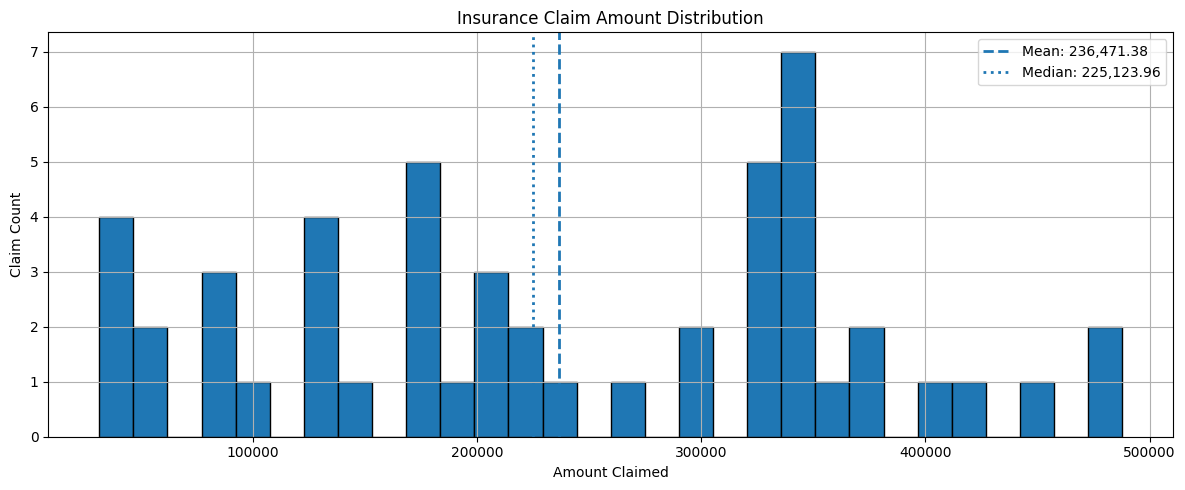

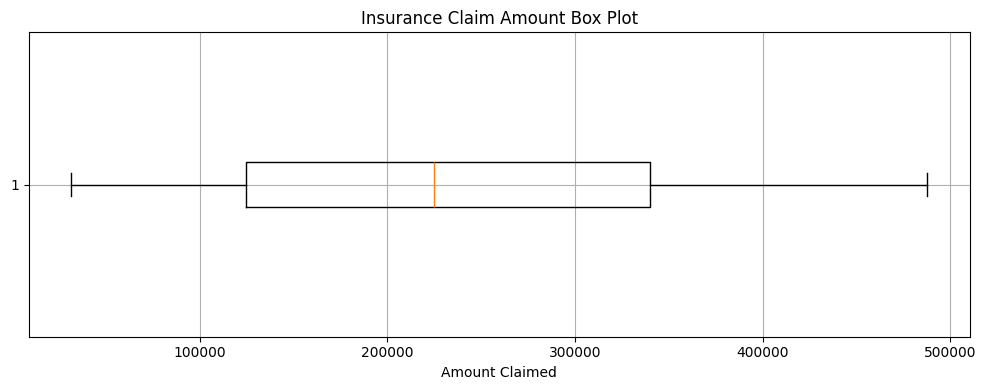

In [4]:
# ── Cell 4: Claim Amount Distribution — Histogram and Box Plot ────────────────
# A histogram shows how values are distributed across ranges.
# BINS divide the value range into equal segments and count how many
# values fall in each bin.
#
# What to look for:
#   Normal pattern      → claims cluster around a typical claim amount
#   Right skewed        → most claims are low, a few are very high
#   Extreme values      → possible fraud, claim processing errors, or data issues

if "amount_claimed" in analysis_df.columns:
    claim_amount = pd.to_numeric(analysis_df["amount_claimed"], errors="coerce").dropna()

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.hist(claim_amount, bins=30, edgecolor="black")
    ax.axvline(claim_amount.mean(), linestyle="--", linewidth=2, label=f"Mean: {claim_amount.mean():,.2f}")
    ax.axvline(claim_amount.median(), linestyle=":", linewidth=2, label=f"Median: {claim_amount.median():,.2f}")
    ax.set_title("Insurance Claim Amount Distribution")
    ax.set_xlabel("Amount Claimed")
    ax.set_ylabel("Claim Count")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "insurance_claim_amount_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.boxplot(claim_amount, vert=False)
    ax.set_title("Insurance Claim Amount Box Plot")
    ax.set_xlabel("Amount Claimed")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "insurance_claim_amount_boxplot.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Column 'amount_claimed' not found.")


,policy_type,total_claims,total_claim_amount,average_claim_amount_per_claim,rank
2,Disability,6,2093330.18,348888.36,1
1,Business,4,1276920.66,319230.17,2
5,Life,3,946469.84,315489.95,3
0,Auto,6,1783549.95,297258.32,4
3,Health,13,2436804.23,187446.48,5
6,Travel,8,1480282.09,185035.26,6
4,Home,10,1806212.23,180621.22,7


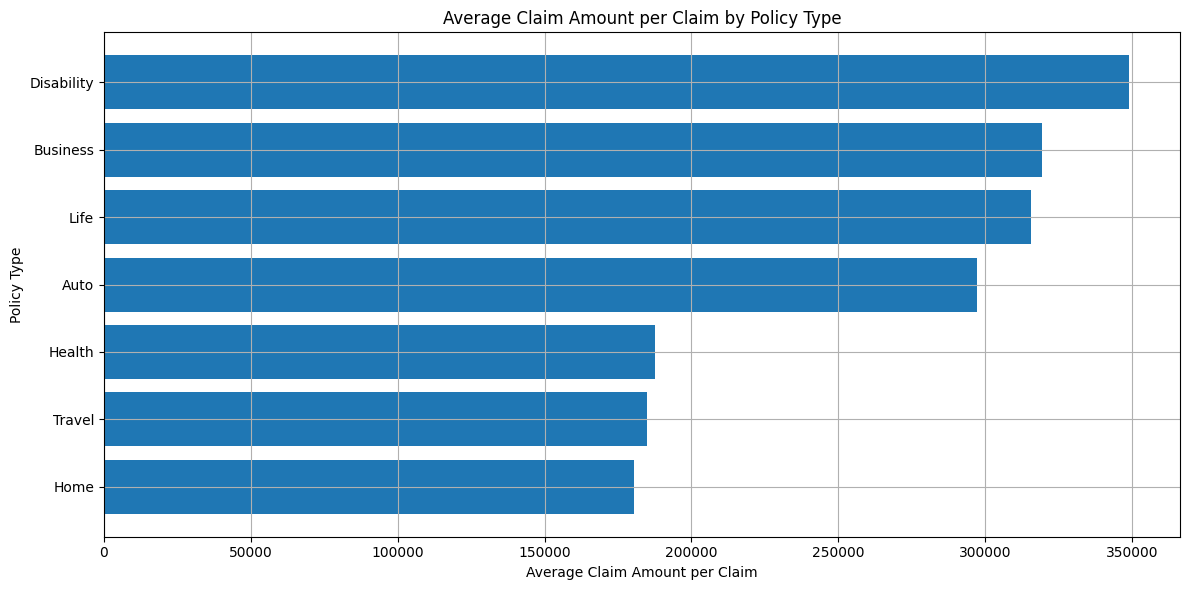

In [6]:
# ── Cell 5: Claim Amount Performance by Policy Type ──────────────────────────────
# Bar charts are the most intuitive way to compare group-level metrics.
# Here we rank insurance policy types by average claim amount per claim.

if {"policy_type", "amount_claimed"}.issubset(analysis_df.columns):
    policy_type_claim_amount = (
        analysis_df
        .groupby("policy_type", dropna=False)
        .agg(
            total_claims=("amount_claimed", "count"),
            total_claim_amount=("amount_claimed", "sum"),
            average_claim_amount_per_claim=("amount_claimed", "mean")
        )
        .reset_index()
        .sort_values("average_claim_amount_per_claim", ascending=False)
    )

    policy_type_claim_amount["rank"] = range(1, len(policy_type_claim_amount) + 1)

    display(policy_type_claim_amount.round(2))

    plot_df = policy_type_claim_amount.sort_values("average_claim_amount_per_claim", ascending=True)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.barh(plot_df["policy_type"].astype(str), plot_df["average_claim_amount_per_claim"])
    ax.set_title("Average Claim Amount per Claim by Policy Type")
    ax.set_xlabel("Average Claim Amount per Claim")
    ax.set_ylabel("Policy Type")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "claim_amount_by_policy_type.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Required columns not found: policy_type and amount_claimed.")


,claim_type,total_claims,total_claim_amount,average_claim_amount_per_claim,rank
3,Medical,12,3616211.98,301351.00,1
4,Natural Disaster,4,1104438.22,276109.56,2
7,Travel Disruption,3,711752.42,237250.81,3
6,Theft,11,2541293.39,231026.67,4
1,Disability,7,1599651.50,228521.64,5
0,Auto Accident,2,385061.18,192530.59,6
5,Property Damage,10,1765337.49,176533.75,7
2,Liability,1,99823.00,99823.00,8


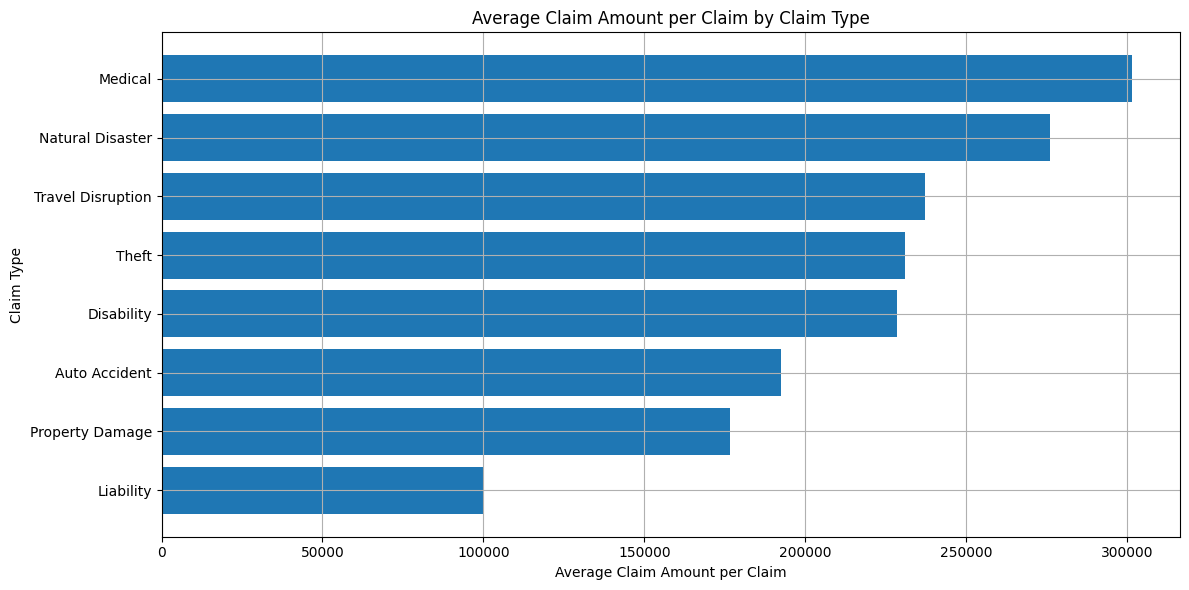

In [7]:
# ── Cell 6: Claim Amount Performance by Claim Type ─────────────────────────────────
# This shows which claim types generate the highest average claim amount per claim.
# It also helps identify high-cost claim categories before management review.

if {"claim_type", "amount_claimed"}.issubset(analysis_df.columns):
    claim_type_claim_amount = (
        analysis_df
        .groupby("claim_type", dropna=False)
        .agg(
            total_claims=("amount_claimed", "count"),
            total_claim_amount=("amount_claimed", "sum"),
            average_claim_amount_per_claim=("amount_claimed", "mean")
        )
        .reset_index()
        .sort_values("average_claim_amount_per_claim", ascending=False)
    )

    claim_type_claim_amount["rank"] = range(1, len(claim_type_claim_amount) + 1)

    display(claim_type_claim_amount.round(2))

    plot_df = claim_type_claim_amount.sort_values("average_claim_amount_per_claim", ascending=True)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.barh(plot_df["claim_type"].astype(str), plot_df["average_claim_amount_per_claim"])
    ax.set_title("Average Claim Amount per Claim by Claim Type")
    ax.set_xlabel("Average Claim Amount per Claim")
    ax.set_ylabel("Claim Type")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "claim_amount_by_claim_type.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Required columns not found: claim_type and amount_claimed.")


In [9]:
# ── Cell 7: Claim Type Performance Relative to Policy Type Average ───────────────
# The business question asks:
# Which claim types are above or below the policy_type average?
#
# We compare each policy_type/claim_type average claim amount per claim against the
# overall policy_type average claim amount per claim.

required_cols = {"claim_type", "policy_type", "amount_claimed"}

if required_cols.issubset(analysis_df.columns):
    policy_claim_type = (
        analysis_df
        .groupby(["policy_type", "claim_type"], dropna=False)
        .agg(
            claims_count=("amount_claimed", "count"),
            policy_claim_type_avg=("amount_claimed", "mean")
        )
        .reset_index()
    )

    policy_type_avg = (
        analysis_df
        .groupby("policy_type", dropna=False)
        .agg(policy_type_avg=("amount_claimed", "mean"))
        .reset_index()
    )

    performance = policy_claim_type.merge(policy_type_avg, on="policy_type", how="left")
    performance["difference_from_policy_type_avg"] = (
        performance["policy_claim_type_avg"] - performance["policy_type_avg"]
    ).round(2)

    performance["performance_flag"] = np.where(
        performance["difference_from_policy_type_avg"] > 0,
        "Above Policy Average",
        "At or Below Policy Average"
    )

    above_average = (
        performance[performance["performance_flag"] == "Above Policy Average"]
        .sort_values("difference_from_policy_type_avg", ascending=False)
    )

    print("Claim type/policy type combinations above the policy average:")
    display(above_average.round(2))

else:
    print("Required columns not found: claim_type, policy_type, amount_claimed.")


Claim type/policy type combinations above the policy average:


,policy_type,claim_type,claims_count,policy_claim_type_avg,policy_type_avg,difference_from_policy_type_avg,performance_flag
20,Travel,Medical,1,402092.79,185035.26,217057.53,Above Policy Average
14,Home,Natural Disaster,2,349112.41,180621.22,168491.19,Above Policy Average
11,Health,Property Damage,2,321677.42,187446.48,134230.94,Above Policy Average
18,Life,Theft,2,433924.09,315489.95,118434.14,Above Policy Average
6,Disability,Theft,1,446863.36,348888.36,97975.00,Above Policy Average
19,Travel,Disability,1,271477.82,185035.26,86442.56,Above Policy Average
5,Disability,Property Damage,1,413821.50,348888.36,64933.14,Above Policy Average
2,Auto,Property Damage,1,354549.97,297258.32,57291.64,Above Policy Average
13,Home,Auto Accident,1,233192.90,180621.22,52571.68,Above Policy Average
22,Travel,Travel Disruption,3,237250.81,185035.26,52215.55,Above Policy Average


  RISK SCORE IMPACT
Pearson correlation between risk_score and amount_claimed: 0.1531
Interpretation: Risk score has weak or negligible linear relationship with claim amount.


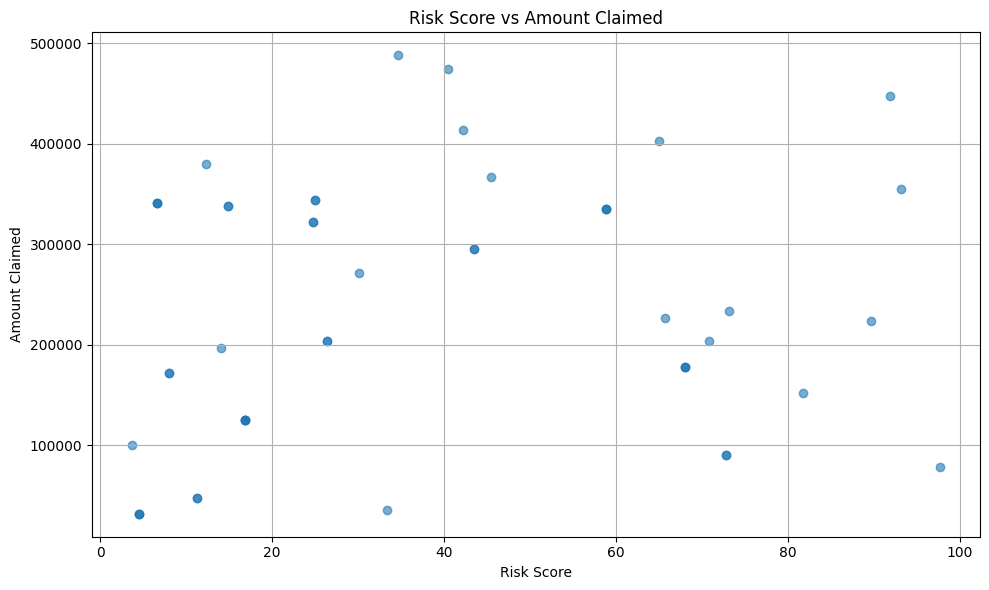

In [10]:
# ── Cell 8: Risk Score Impact — Pearson Correlation ───────────────────────
# The business question asks:
# Does a higher risk_score actually correlate with higher claim amounts?
#
# Here we compute the Pearson correlation between risk_score and amount_claimed.
# Positive correlation: higher risk scores are associated with higher claim amounts.
# Negative correlation: higher risk scores are associated with lower claim amounts.
# Near zero: risk_score has little linear relationship with claim amount.

if {"risk_score", "amount_claimed"}.issubset(analysis_df.columns):
    risk_score = pd.to_numeric(analysis_df["risk_score"], errors="coerce")
    claim_amount = pd.to_numeric(analysis_df["amount_claimed"], errors="coerce")

    corr = risk_score.corr(claim_amount)

    print("=" * 60)
    print("  RISK SCORE IMPACT")
    print("=" * 60)
    print(f"Pearson correlation between risk_score and amount_claimed: {corr:.4f}")

    if corr < -0.3:
        print("Interpretation: Higher risk scores are associated with lower claim amounts.")
    elif corr > 0.3:
        print("Interpretation: Higher risk scores are associated with higher claim amounts.")
    else:
        print("Interpretation: Risk score has weak or negligible linear relationship with claim amount.")

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(risk_score, claim_amount, alpha=0.6)
    ax.set_title("Risk Score vs Amount Claimed")
    ax.set_xlabel("Risk Score")
    ax.set_ylabel("Amount Claimed")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "risk_score_vs_amount_claimed.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Required columns not found: risk_score and amount_claimed.")


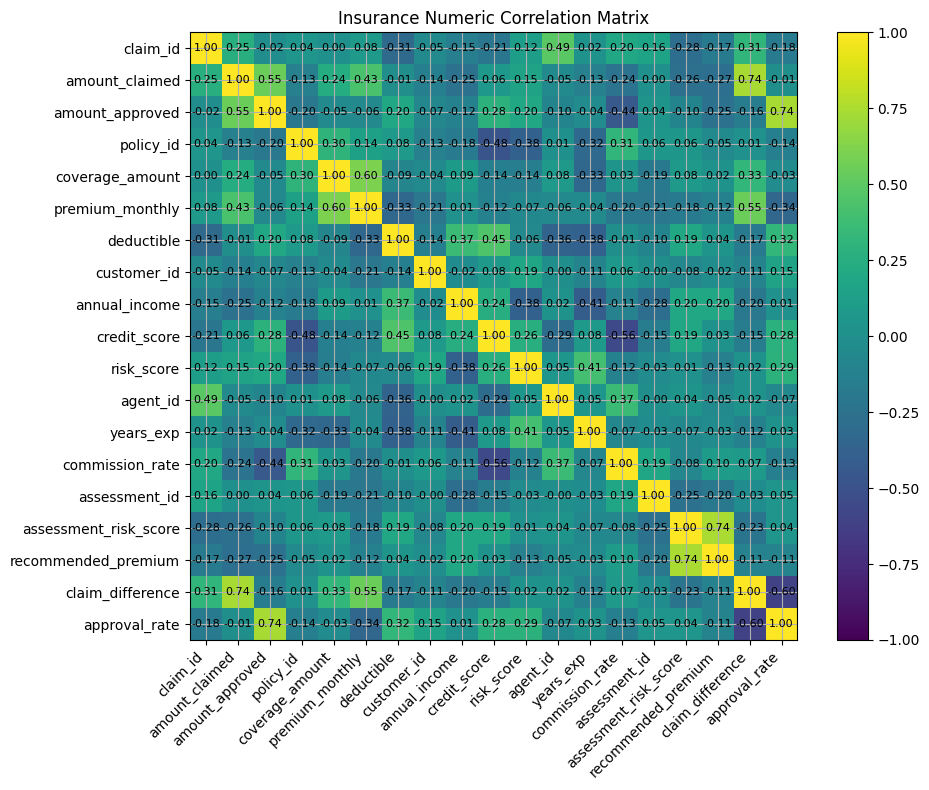

In [17]:
# ── Cell 9: Correlation Heatmap ───────────────────────────────────────────
# A heatmap visualises the entire correlation matrix at once.
# Each cell is coloured by the correlation value:
#   Positive value → variables move together
#   Negative value → one variable rises while the other falls
#   Near zero      → weak linear relationship
#
# This is how analysts quickly identify:
#   - Which insurance metrics are strongly related to claim amount
#   - Which features are redundant or related to each other


FIGURES_DIR.mkdir(parents=True, exist_ok=True)

numeric_df = analysis_df.select_dtypes(include=["number"])

if numeric_df.shape[1] >= 2:
    corr_df = numeric_df.corr()

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(corr_df, vmin=-1, vmax=1)

    ax.set_xticks(range(len(corr_df.columns)))
    ax.set_yticks(range(len(corr_df.columns)))
    ax.set_xticklabels(corr_df.columns, rotation=45, ha="right")
    ax.set_yticklabels(corr_df.columns)

    for i in range(len(corr_df.columns)):
        for j in range(len(corr_df.columns)):
            ax.text(j, i, f"{corr_df.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

    ax.set_title("Insurance Numeric Correlation Matrix")
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "insurance_correlation_matrix.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Not enough numeric columns for correlation heatmap.")


In [12]:
# ── Cell 10: Anomaly Detection ────────────────────────────────────────────
# Now we run the AnomalyDetector on the loaded data.
# Confirmed anomalies are those flagged by BOTH IQR and Z-score.
#
# For insurance, the most important anomaly columns are usually:
#   amount_claimed, amount_approved, risk_score, premium_monthly, coverage_amount, deductible

detector = AnomalyDetector(engine.df)
detector.run(columns=[
    col for col in [
        "amount_claimed",
        "amount_approved",
        "risk_score",
        "premium_monthly",
        "coverage_amount",
        "deductible",
        "claim_difference",
        "approval_rate"
    ]
    if col in engine.df.columns
])

print("Anomaly Detection Summary:")
print(detector.summary().to_string(index=False))
print(f"\nTotal confirmed anomaly rows: {len(detector.confirmed):,}")

if len(detector.confirmed) > 0:
    display(detector.confirmed.head(20))


2026-05-24 14:54:08 [INFO] AnomalyDetector initialised — 50 rows to scan
2026-05-24 14:54:08 [INFO] [ANOMALY] amount_claimed: IQR=0 | Z-score=0 | Confirmed=0
2026-05-24 14:54:08 [INFO] [ANOMALY] amount_approved: IQR=3 | Z-score=1 | Confirmed=1
2026-05-24 14:54:08 [INFO] [ANOMALY] risk_score: IQR=0 | Z-score=0 | Confirmed=0
2026-05-24 14:54:08 [INFO] [ANOMALY] premium_monthly: IQR=0 | Z-score=0 | Confirmed=0
2026-05-24 14:54:08 [INFO] [ANOMALY] coverage_amount: IQR=0 | Z-score=0 | Confirmed=0
2026-05-24 14:54:08 [INFO] [ANOMALY] deductible: IQR=0 | Z-score=0 | Confirmed=0
2026-05-24 14:54:08 [INFO] [ANOMALY] claim_difference: IQR=0 | Z-score=0 | Confirmed=0
2026-05-24 14:54:08 [INFO] [ANOMALY] approval_rate: IQR=0 | Z-score=0 | Confirmed=0
2026-05-24 14:54:08 [INFO] [ANOMALY] Scan complete: 1 confirmed anomaly rows found


Anomaly Detection Summary:
          column  iqr_flagged  zscore_flagged  confirmed_anomalies  anomaly_pct
  amount_claimed            0               0                    0          0.0
 amount_approved            3               1                    1          2.0
      risk_score            0               0                    0          0.0
 premium_monthly            0               0                    0          0.0
 coverage_amount            0               0                    0          0.0
      deductible            0               0                    0          0.0
claim_difference            0               0                    0          0.0
   approval_rate            0               0                    0          0.0

Total confirmed anomaly rows: 1


,claim_id,claim_date,incident_date,claim_type,description,amount_claimed,amount_approved,claim_status,processed_date,is_fraudulent,...,approval_rate,claim_month,is_large_claim,amount_claimed_is_outlier,amount_approved_is_outlier,risk_score_is_outlier,is_any_outlier,_industry,_processed_at,_pipeline_version
25,15,2020-07-07,2022-05-05,Property Damage,Theft of personal property,413821.5,373803.53,Under Review,2020-02-17,False,...,90.33,2020-07,True,False,True,False,True,insurance,2026-05-24T14:38:11.575867,1.0.0


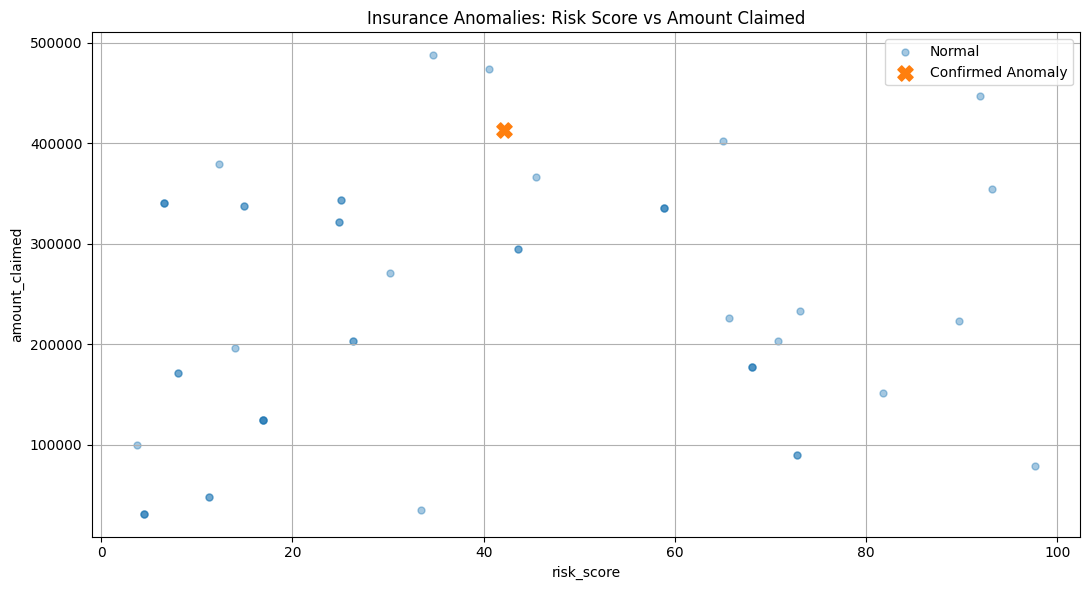

In [13]:
# ── Cell 11: Visualise Anomalies ──────────────────────────────────────────
# Show which rows are anomalies on the scatter plot.
# Normal rows = small circles
# Anomaly rows = large X marks
#
# For insurance, amount_claimed is the main Y-axis because unusual claim amounts
# are important for fraud review, claims control, and risk-management investigation.

x_col = "risk_score" if "risk_score" in engine.df.columns else None
y_col = "amount_claimed" if "amount_claimed" in engine.df.columns else None

if len(detector.confirmed) > 0 and x_col and y_col:
    analysis_df = engine.df.drop(
        columns=[c for c in engine.df.columns if c.startswith("_")],
        errors="ignore"
    )

    normal_mask = ~engine.df.index.isin(detector.confirmed.index)
    normal_rows = analysis_df[normal_mask]
    anomaly_rows = analysis_df[~normal_mask]

    fig, ax = plt.subplots(figsize=(11, 6))

    ax.scatter(
        normal_rows[x_col],
        normal_rows[y_col],
        alpha=0.4,
        s=25,
        label="Normal"
    )

    ax.scatter(
        anomaly_rows[x_col],
        anomaly_rows[y_col],
        marker="X",
        s=120,
        label="Confirmed Anomaly"
    )

    ax.set_title("Insurance Anomalies: Risk Score vs Amount Claimed")
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "insurance_anomalies_scatter.png", dpi=300, bbox_inches="tight")
    plt.show()

elif len(detector.confirmed) == 0:
    print("No confirmed anomalies to visualise.")
else:
    print("Required plotting columns not found.")


In [14]:
# ── Cell 12: Save Anomalies for Review ───────────────────────────────────
# The anomalies file can be opened in Excel by the insurance claims team.
# This supports human investigation of unusual claim records.

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
detector.save_anomalies()

print(f"Anomalies saved to: {REPORTS_DIR / 'anomalies.csv'}")


2026-05-24 14:54:23 [INFO] [ANOMALY] 1 anomaly rows saved: C:\student-projects eda\P03-insurance-eda\reports\anomalies.csv


Anomalies saved to: C:\student-projects eda\P03-insurance-eda\reports\anomalies.csv


## Summary and Next Steps

You have completed the EDA for this insurance dataset. Record your key findings below:

### Key Findings

| Finding | Value | Action |
|---|---|---|
| Top policy_type by average claim amount per claim | *fill in* | Review pricing and risk strategy |
| Top claim_type by average claim amount per claim | *fill in* | Compare against high-risk claim categories |
| Risk score vs claim amount correlation | *fill in* | Decide whether risk scoring aligns with claim exposure |
| Anomaly rows confirmed | *fill in* | Review suspicious insurance anomalies.csv |

### Next Steps
- **Claims review**: Focus on high-cost and unusual claim types.
- **Policy risk review**: Investigate policy types with above-average claim amounts.
- **Risk score review**: Use the correlation result to decide whether risk scores are aligned with claim amount exposure.
- **Anomaly review**: Open `reports/anomalies.csv` and investigate unusual insurance claims.

### Questions for the Insurance Risk Manager
1. Which policy types should receive more pricing or underwriting review?
2. Which claim types require stronger fraud checks or operational support?
3. Are current risk scores predicting claim amount exposure effectively?
